In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import RFE, SelectKBest, f_classif, mutual_info_classif, mutual_info_regression,f_regression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier ,GradientBoostingRegressor,IsolationForest
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.linear_model import Ridge, Lasso
import xgboost as xgb
import plotly.graph_objects as go
import plotly.express as px

In [29]:
# ------------------------------
# 1. Load Data, Drop COVID Anomaly & Engineer Targets
# ------------------------------
df = pd.read_csv('cleaned_new_data.csv')

# Drop COVID anomaly year only (keep 2026 — used as test boundary)
df = df[df['Year'] != 2021].reset_index(drop=True)

repetition_cols = [f'g{i}_repetition' for i in range(1, 13)]
df['avg_repetition_rate'] = df[repetition_cols].mean(axis=1)

dropout_cols = [f'g{i}_dropout' for i in range(1, 13)]
df['avg_dropout_rate'] = df[dropout_cols].mean(axis=1)
overage_cols = ["pct_overage_enrollment_primary", "pct_overage_enrollment_lower_sec", "pct_overage_enrollment_upper_sec"]
df["over_age_enrollment_total"]=df[overage_cols].sum(axis = 1)
df['kids_population']=df[["pop_aged6_total","pop_aged6_11_total","pop_aged12_14_total","pop_aged15_17_total"]].sum(axis=1)
df['bad_qual_teacher']= df[["teaching_staff_edu_primary","teaching_staff_edu_lower_sec","teaching_staff_edu_upper_sec"]].sum(axis=1)
df['good_qual_teacher']= df[["teaching_staff_edu_graduate","teaching_staff_edu_postgrad","teaching_staff_edu_phd"]].sum(axis=1)
# avg_promotion_rate removed — unused downstream


In [30]:
# ------------------------------
# 2. Staff Qualification Feature Engineering
# ------------------------------
edu_levels = ["primary", "lower_sec", "upper_sec", "graduate", "postgrad", "phd"]
weights = {"primary": 1, "lower_sec": 2, "upper_sec": 3, "graduate": 4, "postgrad": 5, "phd": 6}

# No-pedagogy ratio
df["no_pedagogy_ratio"] = (
    df[[f"teaching_staff_no_pedagogy_{l}" for l in edu_levels]].sum(axis=1)
    / df["teaching_staff_total"].replace(0, pd.NA)
)

# High/low qual ratio (teaching staff)
df["teaching_high_qual_ratio"] = (
    df[[f"teaching_staff_edu_{l}" for l in ["graduate", "postgrad", "phd"]]].sum(axis=1)
    / df["teaching_staff_total"].replace(0, pd.NA)
)
df["teaching_low_qual_ratio"] = (
    df[[f"teaching_staff_edu_{l}" for l in ["primary", "lower_sec", "upper_sec"]]].sum(axis=1)
    / df["teaching_staff_total"].replace(0, pd.NA)
)

# Qualification index per staff group
for prefix in ["teaching_staff_edu", "non_teaching_staff_edu", "teaching_staff_no_pedagogy"]:
    weighted_sum = sum(df[f"{prefix}_{level}"] * w for level, w in weights.items())
    total = df[[f"{prefix}_{level}" for level in edu_levels]].sum(axis=1).replace(0, pd.NA)
    df[f"{prefix}_qual_index"] = weighted_sum / total


In [31]:
df['bad_qual_teacher']= df[["teaching_staff_edu_primary","teaching_staff_edu_lower_sec","teaching_staff_edu_upper_sec"]].sum(axis=1)
df['good_qual_teacher']= df[["teaching_staff_edu_graduate","teaching_staff_edu_postgrad","teaching_staff_edu_phd"]].sum(axis=1)
    

In [32]:
features_list_enrollment = [
    "Province","Year",
    "enrollment_total",
    "classroom_area_per_student",
    "wooden_rooms",
    "pb_fund_per_school_riel",
    "bamboo_buildings",
    "pct_schools_two_shift",
    "bamboo_rooms",
    "pct_schools_in_pagoda",
    "pupil_teacher_ratio",
    "funding_community",
    "pupil_classroom_ratio",
    "schools_with_library",
    "bad_qual_teacher",
    "total_staff_total",
    "kids_population",
    "num_classrooms",
]

drop_out_features = [
    "Province","Year",
    "avg_dropout_rate",
    "pct_schools_in_pagoda",
    "principal_avg_service_years",
    "good_qual_teacher",
    "pb_fund_per_school_riel",
    "total_staff_total",
    "bad_qual_teacher",
    "kids_population",
    "num_classrooms",
    "schools_with_library",
    "schools_with_office",
    "pct_schools_two_shift",
    "pct_overage_enrollment_lower_sec",
    "pupil_teacher_ratio",
    "pct_overage_enrollment_primary",
    "pct_overage_total_lower_sec",
    "wooden_rooms",
]

teacher_quality_features = [
    "Province","Year",
    "teaching_staff_edu_qual_index",
    "classroom_area_per_student",
    "wooden_rooms",
    "pct_schools_two_shift",
    "pupil_teacher_ratio",
    "bamboo_buildings",
    "bamboo_rooms",
    "funding_abroad",
    "schools_without_water",
    "pb_fund_per_school_riel",
    "funding_ios_ngos",
    "num_classrooms",
    "schools_with_office",
    "schools_with_library",
    "pct_schools_in_pagoda",
    "preschool_with_sport_facility",
]

In [33]:
def corr_heatmap(df, target, feature_cols, title):
    cols = [c for c in feature_cols if c in df.columns and c != target]
    corr = df[cols + [target]].corr()[[target]].drop(target)
    corr.columns = ["correlation"]

    # Get the 5 largest positive and 5 largest negative correlations
    top_positive = corr.nlargest(5, "correlation")
    top_negative = corr.nsmallest(10, "correlation")

    # Combine and sort them
    corr = (
        pd.concat([top_negative, top_positive])
        .drop_duplicates()
        .sort_values("correlation")
    )

    fig = px.imshow(
        corr,
        color_continuous_scale="RdBu_r",
        zmin=-1,
        zmax=1,
        aspect="auto",
        text_auto=".2f",
        title=title,
    )
    fig.update_layout(
        height=max(300, len(corr) * 44),
        coloraxis_colorbar=dict(title="r"),
    )

    fig.show()


def plot_features_grid(df, features, target):
    # Ensure column names match lowercase
    df.columns = [c.lower() for c in df.columns]
    features = [f.lower() for f in features]
    target = target.lower()

    # --- Apply Dark Theme Styling ---
    plt.style.use("dark_background")
    rc_params = {
        "figure.facecolor": "#11141a",
        "axes.facecolor": "#11141a",
        "axes.edgecolor": "#31333f",
        "grid.color": "#31333f",
        "text.color": "#ffffff",
        "axes.labelcolor": "#a3a8b4",
        "xtick.color": "#a3a8b4",
        "ytick.color": "#a3a8b4",
    }
    plt.rcParams.update(rc_params)

    # Setup a dynamic 1-row grid based on the number of features passed
    fig, axes = plt.subplots(1, len(features), figsize=(6 * len(features), 5))

    # If only 1 feature is passed, convert axes to an array to keep code consistent
    if len(features) == 1:
        axes = [axes]

    fig.suptitle(
        f"Features vs {target.replace('_', ' ').title()}",
        fontsize=22,
        color="#ffffff",
        weight="bold",
    )

    # Vibrant neon/pastel palette
    colors = sns.color_palette("coolwarm", len(features))

    # Loop through features and populate the subplots dynamically
    for i, feature in enumerate(features):
        ax = axes[i]  # Clean 1D array indexing

        if feature in df.columns:
            sns.regplot(
                data=df,
                x=feature,
                y=target,
                ax=ax,
                scatter_kws={"alpha": 0.6, "color": colors[i], "s": 40},
                line_kws={"color": "#ff4b4b", "linewidth": 2},
            )
            ax.set_title(
                feature.replace("_", " ").title(), fontsize=12, color="#ffffff", pad=10
            )
            ax.set_xlabel(feature.replace("_", " ").title(), fontsize=10)
            ax.set_ylabel(target.replace("_", " ").title(), fontsize=10)
            ax.grid(True, linestyle="--", alpha=0.1)
        else:
            ax.text(
                0.5,
                0.5,
                f"Feature '{feature}'\nnot found",
                ha="center",
                va="center",
                fontsize=12,
                color="#ff4b4b",
            )
            ax.axis("off")

    # Adjust layout for neat spacing
    plt.tight_layout(rect=[0, 0.03, 1, 0.90])
    plt.show()
def plot_timeseries_grid(df, features, time_col="Year"):
    # Apply clean dark styling
    plt.style.use("dark_background")

    # Setup 3 rows by 5 columns grid
    fig, axes = plt.subplots(3, 5, figsize=(22, 12))
    axes = axes.flatten()  # Flatten to easily loop over 15 slots

    for i, feature in enumerate(features):
        ax = axes[i]
        if feature in df.columns:
            # sns.lineplot automatically aggregates multiple rows per year (e.g. provinces)
            sns.lineplot(
                data=df,
                x=time_col,
                y=feature,
                ax=ax,
                marker="o",
                linewidth=2,
                color="#00d2ff",
            )
            ax.set_title(feature.replace("_", " ").title(), fontsize=10)
            ax.set_xlabel("")
            ax.set_ylabel("")
            ax.grid(True, linestyle="--", alpha=0.2)
        else:
            ax.axis("off")  # Hide empty subplots if feature is missing

    plt.tight_layout()
    plt.show()

In [34]:
enroll = df[features_list_enrollment]
drop_out = df[drop_out_features]
teacher = df[teacher_quality_features]

In [35]:
def remove_outliers_iforest(df, contamination=0.05):
    numeric_df = df.select_dtypes(include=["number"]).dropna()

    iso = IsolationForest(contamination=contamination, random_state=42)
    preds = iso.fit_predict(numeric_df)

    valid_indices = numeric_df.index[preds == 1]
    yeeted_indices = numeric_df.index[preds == -1]

    print(f"=== YEETED {len(yeeted_indices)} ROWS VIA ISOLATION FOREST ===")
    if not yeeted_indices.empty:
        with pd.option_context(
            "display.max_columns", None, "display.width", 1000
        ):
            print(df.loc[yeeted_indices])
    print("==================================================\n")

    return df.loc[valid_indices].copy()

Isolation Forest isolates outliers by drawing random lines to split your data.

* Normal rows are clustered tightly together, so it takes many splits to isolate them.

* Outliers sit far away from the crowd, so it takes very few splits to isolate them.

It catches relationship anomalies (like a school with 2 classrooms but 1,000 students) because that specific combination sits in a lonely, empty space, causing the algorithm to cut it away from the rest of the data almost instantly.

In [36]:
enroll = remove_outliers_iforest(enroll)

=== YEETED 13 ROWS VIA ISOLATION FOREST ===
       Province  Year  enrollment_total  classroom_area_per_student  wooden_rooms  pb_fund_per_school_riel  bamboo_buildings  pct_schools_two_shift  bamboo_rooms  pct_schools_in_pagoda  pupil_teacher_ratio  funding_community  pupil_classroom_ratio  schools_with_library  bad_qual_teacher  total_staff_total  kids_population  num_classrooms
1    Battambang  2016          233906.0                        1.30        1435.0                3629355.0              19.0                   53.9          48.0                   24.9                 34.6              100.0                   46.1                 328.0            5350.0             8593.0         346260.0          5069.0
14   Phnom Penh  2016          229987.0                        1.00          36.0                7503963.0               0.0                   48.0           0.0                   50.9                 22.9               95.0                   61.7                 220.0       

In [37]:
drop_out = remove_outliers_iforest(drop_out)

=== YEETED 13 ROWS VIA ISOLATION FOREST ===
         Province  Year  avg_dropout_rate  pct_schools_in_pagoda  principal_avg_service_years  good_qual_teacher  pb_fund_per_school_riel  total_staff_total  bad_qual_teacher  kids_population  num_classrooms  schools_with_library  schools_with_office  pct_schools_two_shift  pct_overage_enrollment_lower_sec  pupil_teacher_ratio  pct_overage_enrollment_primary  pct_overage_total_lower_sec  wooden_rooms
1      Battambang  2016         17.308333                   24.9                         21.2             1414.0                3629355.0             8593.0            5350.0         346260.0          5069.0                 328.0                495.0                   53.9                              29.9                 34.6                            14.9                         29.9        1435.0
14     Phnom Penh  2016          9.016667                   50.9                         27.7             3226.0                7503963.0           

In [38]:
teacher = remove_outliers_iforest(teacher)

=== YEETED 13 ROWS VIA ISOLATION FOREST ===
         Province  Year  teaching_staff_edu_qual_index  classroom_area_per_student  wooden_rooms  pct_schools_two_shift  pupil_teacher_ratio  bamboo_buildings  bamboo_rooms  funding_abroad  schools_without_water  pb_fund_per_school_riel  funding_ios_ngos  num_classrooms  schools_with_office  schools_with_library  pct_schools_in_pagoda  preschool_with_sport_facility
1      Battambang  2016                       2.957422                        1.30        1435.0                   53.9                 34.6              19.0          48.0            11.0                  713.0                3629355.0              20.0          5069.0                495.0                 328.0                   24.9                          244.0
17      Prey Veng  2016                       2.847782                        1.24         367.0                   46.8                 41.1               6.0           2.0             7.0                  423.0         

In [39]:
feature1 = [
    "classroom_area_per_student",
    "wooden_rooms",
    "pb_fund_per_school_riel",
    "bamboo_buildings",
    "pct_schools_two_shift",
    "bamboo_rooms",
    "pct_schools_in_pagoda",
    "pupil_teacher_ratio",
    "funding_community",
    "pupil_classroom_ratio",
    "schools_with_library",
    "bad_qual_teacher",
    "total_staff_total",
    "kids_population",
    "num_classrooms",
]

feature2 = [
    "pct_schools_in_pagoda",
    "principal_avg_service_years",
    "good_qual_teacher",
    "pb_fund_per_school_riel",
    "total_staff_total",
    "bad_qual_teacher",
    "kids_population",
    "num_classrooms",
    "schools_with_library",
    "schools_with_office",
    "pct_schools_two_shift",
    "pct_overage_enrollment_lower_sec",
    "pupil_teacher_ratio",
    "pct_overage_enrollment_primary",
    "wooden_rooms",
    "pct_overage_total_upper_sec"
]

feature3 = [
    "classroom_area_per_student",
    "wooden_buildings",
    "pct_schools_two_shift",
    "pupil_teacher_ratio",
    "bamboo_buildings",
    "bamboo_rooms",
    "funding_abroad",
    "schools_without_water",
    "pb_fund_per_school_riel",
    "funding_ios_ngos",
    "num_classrooms",
    "schools_with_office",
    "schools_with_library",
    "pct_schools_in_pagoda",
    "preschool_with_sport_facility",
]

In [40]:
corr_heatmap(enroll,"enrollment_total",feature1,'enrollment')

In [41]:
corr_heatmap(drop_out,"avg_dropout_rate",feature2,'drop_out')

In [42]:
corr_heatmap(teacher,"teaching_staff_edu_qual_index",feature3,'teaching_staff_edu_qual_index')

In [43]:
final_enroll_feature = ["num_classrooms","kids_population","total_staff_total"]
final_dropout_feature = ["pct_overage_enrollment_lower_sec","wooden_rooms","principal_avg_service_years","good_qual_teacher"]
final_teacher_feature = ["pb_fund_per_school_riel","num_classrooms","schools_without_water"]

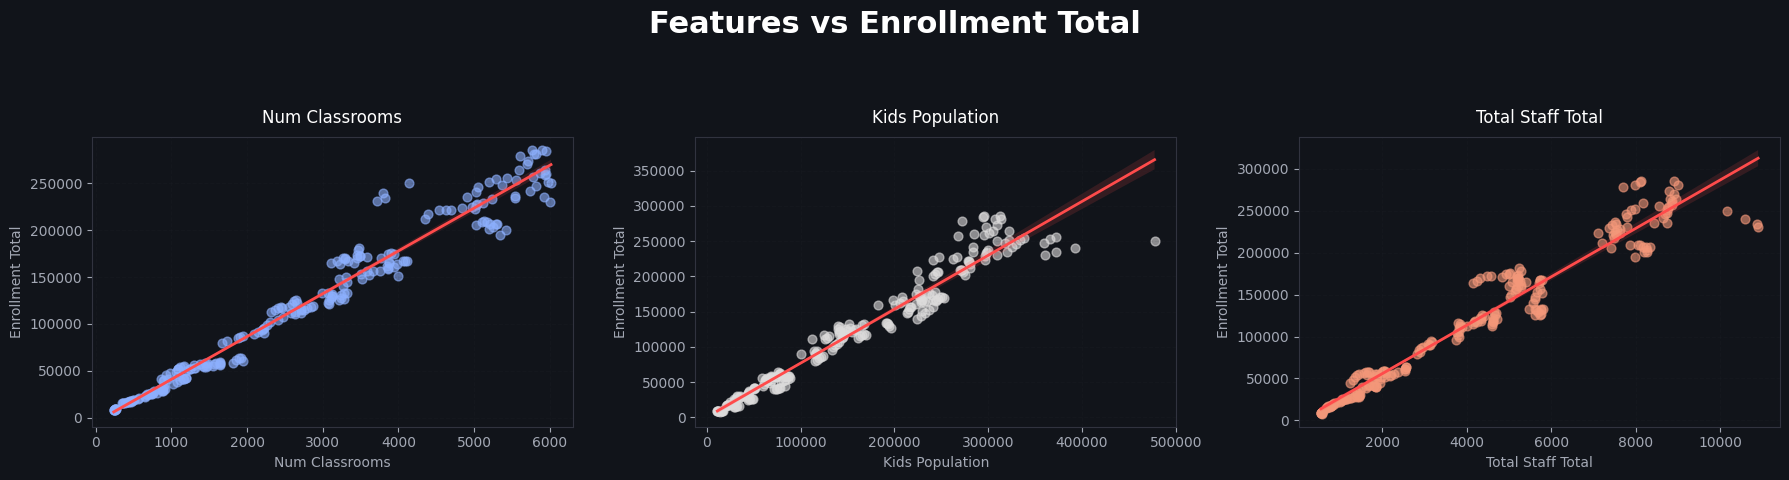

In [44]:
plot_features_grid(enroll,final_enroll_feature,"enrollment_total")

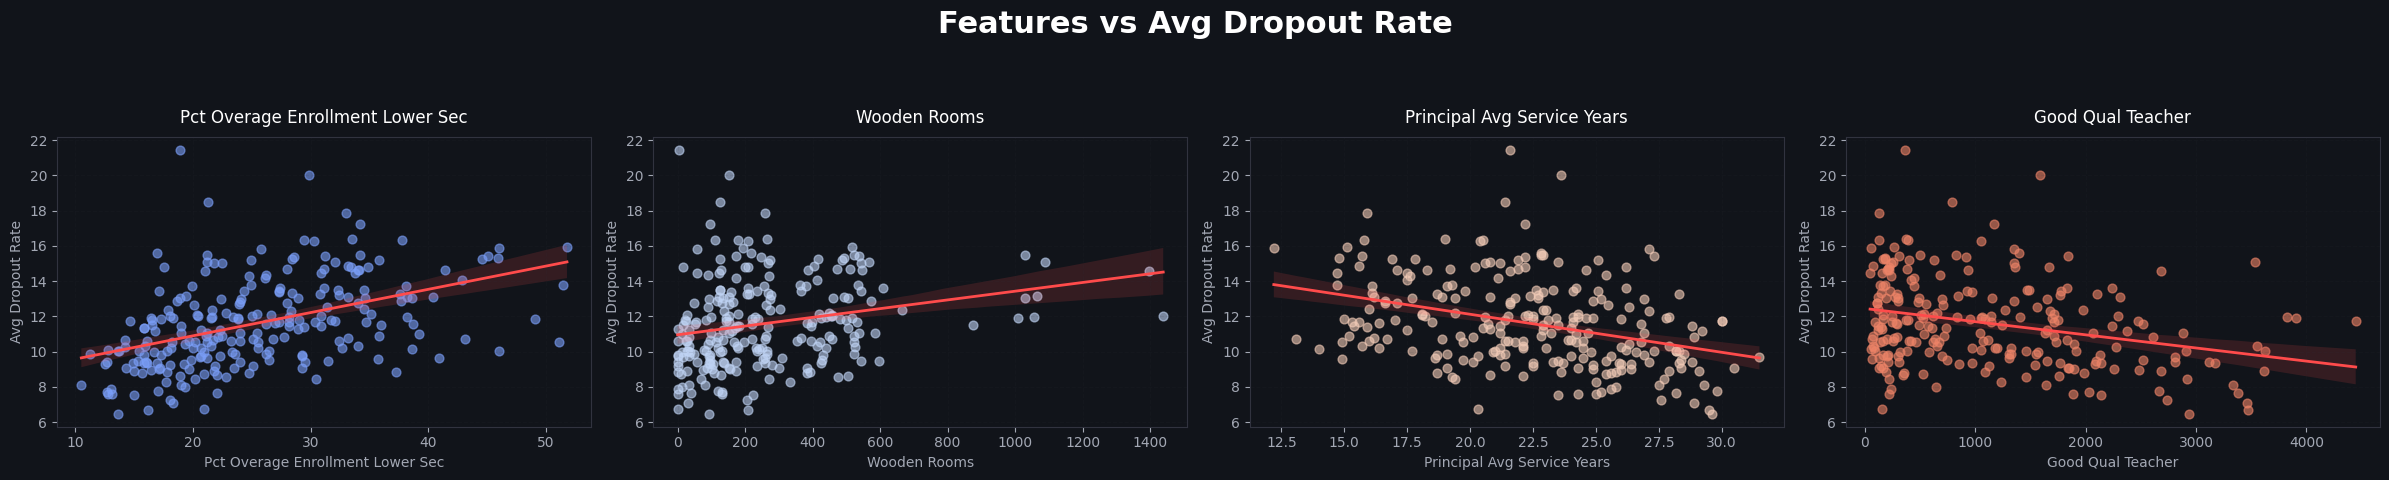

In [45]:
plot_features_grid(drop_out,final_dropout_feature,"avg_dropout_rate")

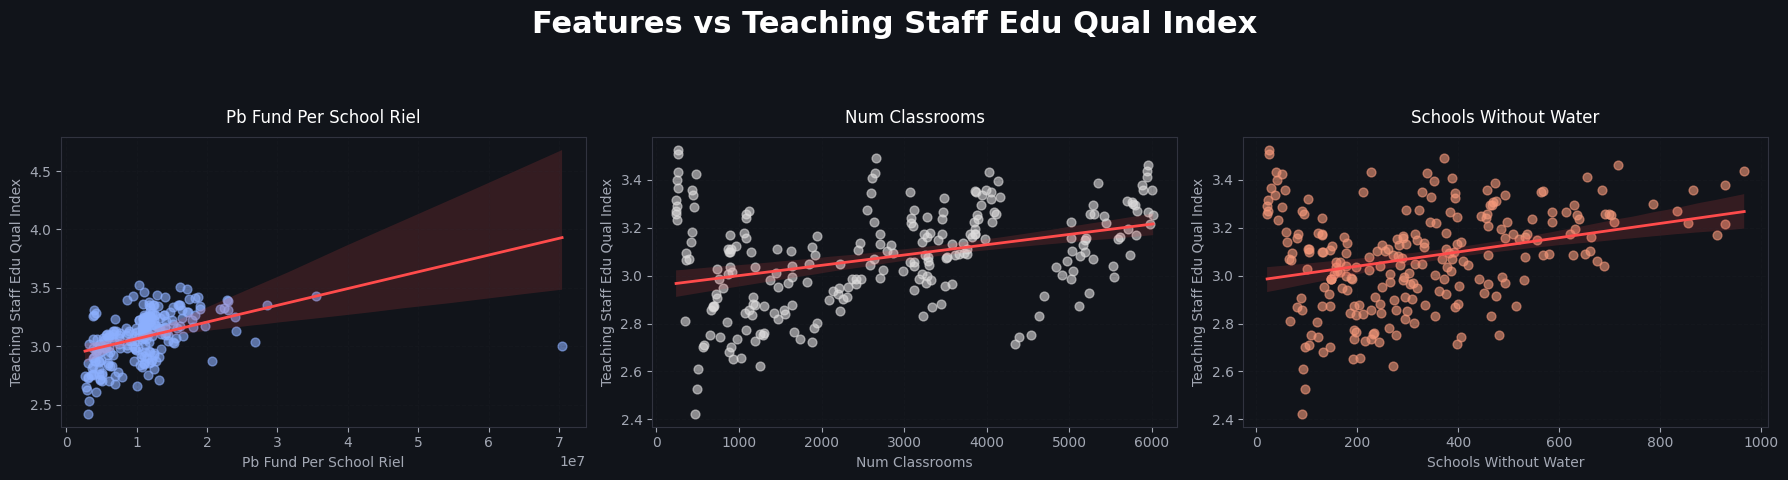

In [46]:
plot_features_grid(teacher,final_teacher_feature,"teaching_staff_edu_qual_index")

In [47]:
# Group by BOTH province and year
provincial_summary = drop_out.groupby('province')[final_dropout_feature + ["avg_dropout_rate"]].mean().reset_index()

# Save for Excel graphing
#provincial_summary.to_excel('dropout.xlsx', index=False)

In [48]:
# Group by BOTH province and year
provincial_summary =teacher.groupby('province')[final_teacher_feature + ["teaching_staff_edu_qual_index"]].mean().reset_index()

# Save for Excel graphing
#provincial_summary.to_excel('teacher.xlsx', index=False)

>>> ENROLLMENT

  TARGET: enrollment_total
            Model      R²       RMSE        MAE
Gradient Boosting  0.9867  9720.5986  6200.5194
    Random Forest  0.9832 10913.1189  7458.3259
            Lasso  0.9805 11769.6911  8393.0656
            Ridge  0.9805 11769.6911  8393.0655
          XGBoost  0.9804 11804.4815  7162.0009
     SVR (Linear) -0.0083 84663.7311 71910.0119
        SVR (RBF) -0.0084 84665.9292 71846.3624



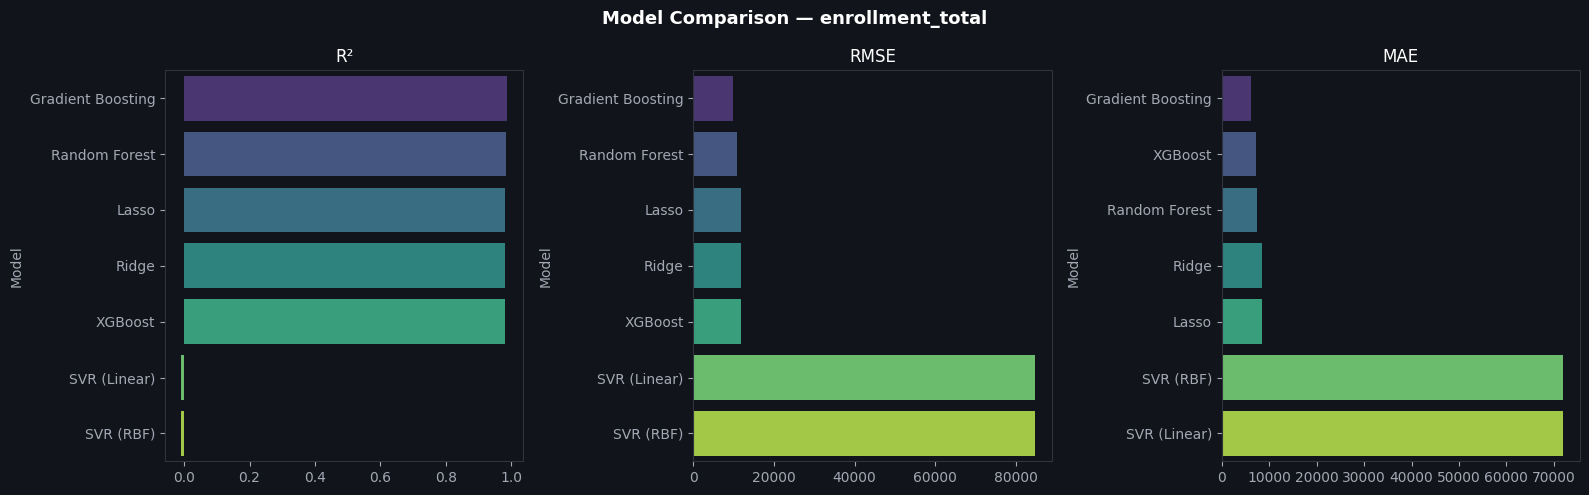

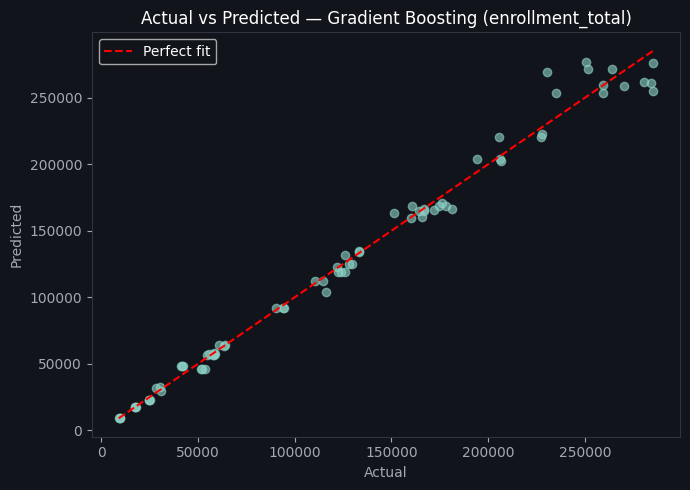

>>> DROPOUT RATE

  TARGET: avg_dropout_rate
            Model      R²   RMSE    MAE
     SVR (Linear) -0.1117 1.8270 1.4967
        SVR (RBF) -0.6630 2.2346 1.8336
            Ridge -0.7259 2.2764 1.9139
            Lasso -0.7265 2.2768 1.9151
    Random Forest -1.0420 2.4761 2.0854
Gradient Boosting -1.0532 2.4829 1.9972
          XGBoost -1.2543 2.6016 2.1028



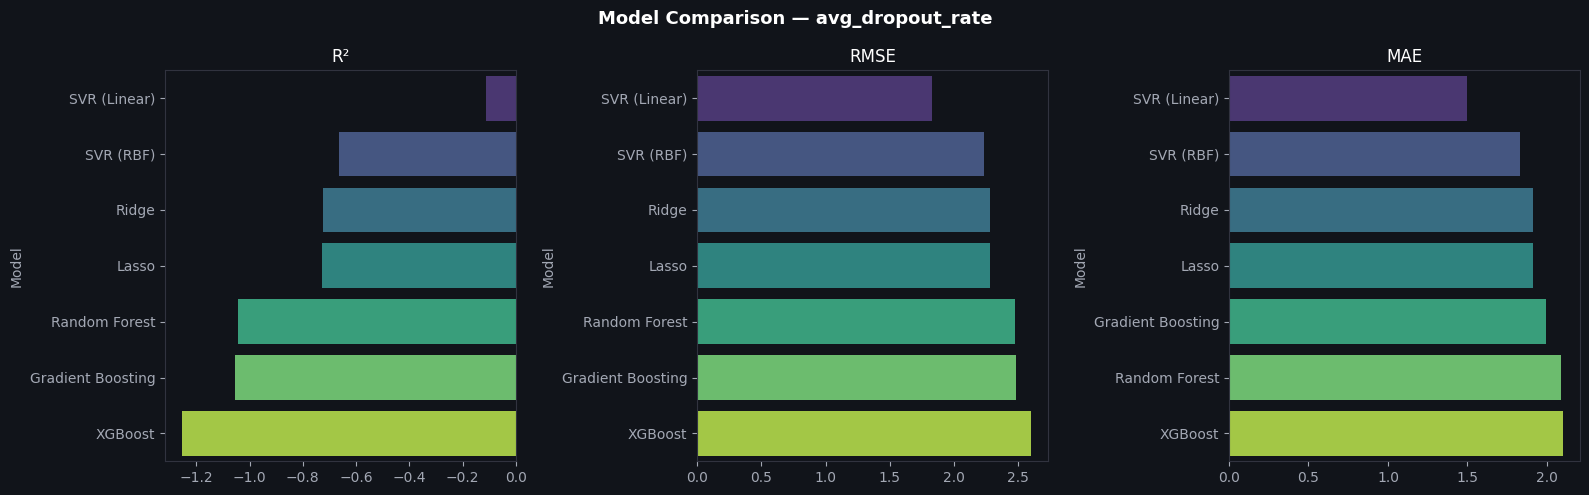

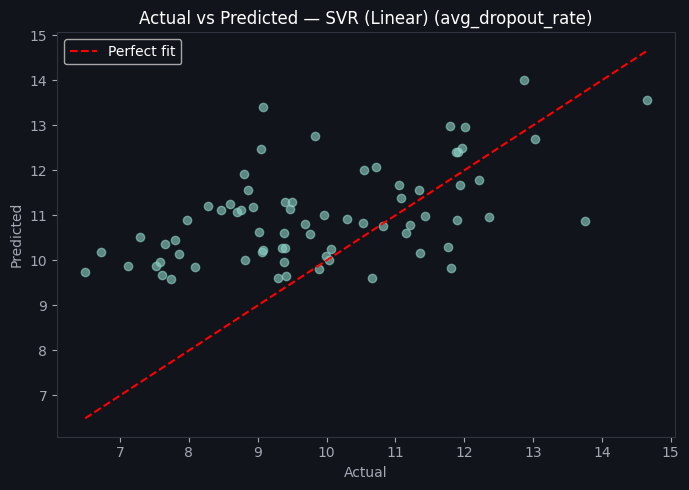

>>> TEACHER QUALITY

  TARGET: teaching_staff_edu_qual_index
            Model      R²   RMSE    MAE
    Random Forest  0.1123 0.1511 0.1302
Gradient Boosting  0.0857 0.1533 0.1292
          XGBoost  0.0677 0.1548 0.1289
        SVR (RBF) -0.2277 0.1777 0.1419
     SVR (Linear) -0.4924 0.1959 0.1512
            Lasso -0.7871 0.2143 0.1759
            Ridge -0.7874 0.2144 0.1760



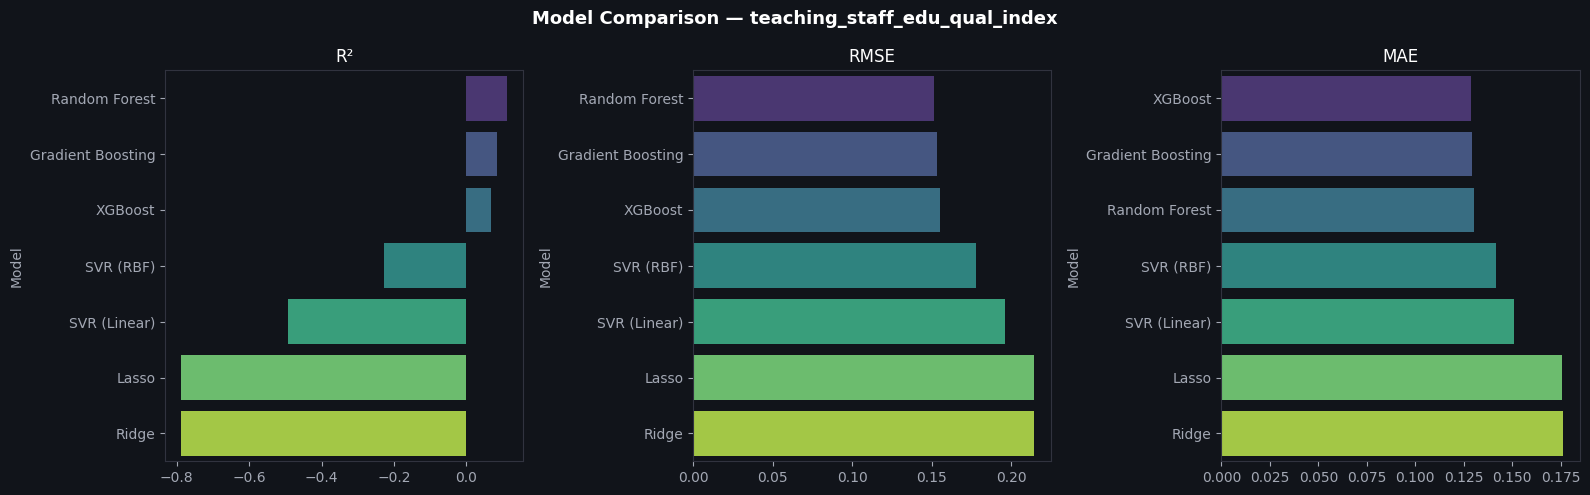

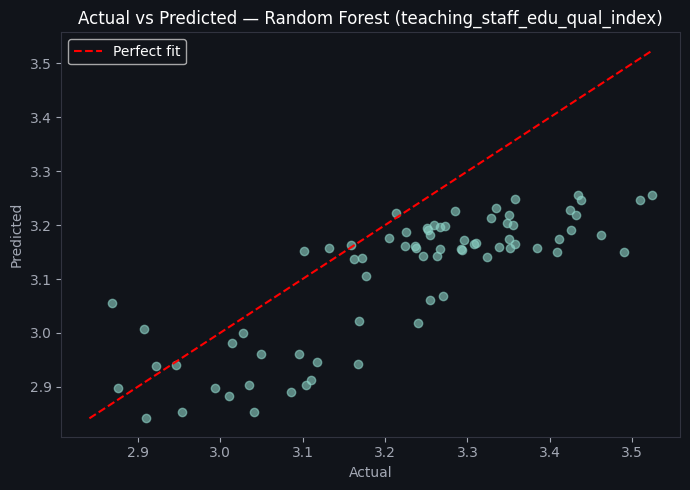

In [49]:
def forecast_compare(df, target, features, train_years=(2016, 2023), test_years=(2024, 2026), log_transform=False):
    """
    Trains multiple models on a time-split, compares MSE/R²/MAE, plots results.
    log_transform=True for skewed ratio targets like dropout rate.
    """

    # --- Prep ---
    feats = [c for c in features if c in df.columns]
    X_raw = df[feats].copy().fillna(np.nan)
    y_raw = df[target].copy()

    train_mask = df['year'].between(*train_years)
    test_mask  = df['year'].between(*test_years)

    X_train, X_test = X_raw[train_mask], X_raw[test_mask]
    y_train, y_test = y_raw[train_mask], y_raw[test_mask]

    imputer = SimpleImputer(strategy='median')
    X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=feats)
    X_test_imp  = pd.DataFrame(imputer.transform(X_test),      columns=feats)

    # Scale for SVR
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train_imp)
    X_test_sc  = scaler.transform(X_test_imp)

    if log_transform:
        y_train_fit = np.log1p(y_train.values)
    else:
        y_train_fit = y_train.values

    # --- Models ---
    models = {
        'Random Forest':       (RandomForestRegressor(n_estimators=150, max_depth=8, min_samples_leaf=4, random_state=42, n_jobs=-1),  X_train_imp, X_test_imp),
        'Gradient Boosting':   (GradientBoostingRegressor(n_estimators=150, max_depth=4, learning_rate=0.05, random_state=42),          X_train_imp, X_test_imp),
        'XGBoost':             (xgb.XGBRegressor(n_estimators=150, max_depth=4, learning_rate=0.05, random_state=42, verbosity=0),      X_train_imp, X_test_imp),
        'SVR (RBF)':           (SVR(kernel='rbf', C=10, epsilon=0.1),                                                                   X_train_sc,  X_test_sc),
        'SVR (Linear)':        (SVR(kernel='linear', C=1),                                                                              X_train_sc,  X_test_sc),
        'Ridge':               (Ridge(alpha=1.0),                                                                                       X_train_imp, X_test_imp),
        'Lasso':               (Lasso(alpha=0.01, max_iter=5000),                                                                       X_train_imp, X_test_imp),
    }

    # --- Evaluate ---
    records = []
    predictions = {}

    for name, (model, X_tr, X_te) in models.items():
        model.fit(X_tr, y_train_fit)
        y_pred_raw = model.predict(X_te)

        # reverse log if needed
        y_pred = np.expm1(y_pred_raw) if log_transform else y_pred_raw
        y_true = y_test.values

        records.append({
            'Model': name,
            'R²':    round(r2_score(y_true, y_pred), 4),
            'RMSE':  round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
            'MAE':   round(mean_absolute_error(y_true, y_pred), 4),
        })
        predictions[name] = y_pred

    results_df = pd.DataFrame(records).sort_values('R²', ascending=False).reset_index(drop=True)

    # --- Print table ---
    print(f"\n{'='*55}")
    print(f"  TARGET: {target}")
    print(f"{'='*55}")
    print(results_df.to_string(index=False))
    print(f"{'='*55}\n")

    # --- Plot 1: metric comparison bar chart ---
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, metric in zip(axes, ['R²', 'RMSE', 'MAE']):
        sorted_df = results_df.sort_values(metric, ascending=(metric != 'R²'))
        sns.barplot(data=sorted_df, x=metric, y='Model', ax=ax,
                    hue='Model', palette='viridis', legend=False)
        ax.set_title(metric)
        ax.set_xlabel('')
    fig.suptitle(f'Model Comparison — {target}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # --- Plot 2: actual vs predicted for best model ---
    best_model_name = results_df.iloc[0]['Model']
    y_best = predictions[best_model_name]

    plt.figure(figsize=(7, 5))
    plt.scatter(y_test.values, y_best, alpha=0.6)
    lims = [min(y_test.min(), y_best.min()), max(y_test.max(), y_best.max())]
    plt.plot(lims, lims, 'r--', label='Perfect fit')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'Actual vs Predicted — {best_model_name} ({target})')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return results_df, predictions


# ==============================
# Run all 3 models
# ==============================

features_enrollment = ['repeaters_total', 'total_staff_total', 'two_shift_schools_lycee',
                        'principal_female', 'num_primary_schools', 'satellite_schools',
                        'num_buildings_total', 'num_rooms_total', 'concrete_brick_buildings',
                        'pupil_teacher_ratio']

features_dropout = ['principal_avg_age', 'principal_avg_service_years',
                    'pct_overage_enrollment_upper_sec', 'sport_volleyball', 'sport_long_jump',
                    'pb_fund_per_school_riel', 'buildings_per_school', 'classes_per_classroom',
                    'pct_overage_admission_total', 'transition_rate_lower_sec_total']

features_teacher = ['schools_without_water', 'schools_without_latrine', 'principal_avg_service_years',
                    'principal_upper_sec_plus_edu', 'buildings_poor_roof', 'pb_fund_per_student_riel',
                    'pb_fund_per_school_riel', 'classrooms_per_school',
                    'gross_admission_rate_total', 'transition_rate_lower_sec_total']

print(">>> ENROLLMENT")
res_enrollment, pred_enrollment = forecast_compare(
    enroll, target='enrollment_total', features=final_enroll_feature, log_transform=False)

print(">>> DROPOUT RATE")
res_dropout, pred_dropout = forecast_compare(
    drop_out, target='avg_dropout_rate', features=final_dropout_feature, log_transform=False)

print(">>> TEACHER QUALITY")
res_teacher, pred_teacher = forecast_compare(
    teacher, target='teaching_staff_edu_qual_index', features=final_teacher_feature, log_transform=False)

In [50]:
from sklearn.preprocessing import PowerTransformer


# ------------------------------------------------------------------
# Features that need log1p (right-skewed at province level)
# ------------------------------------------------------------------
DROPOUT_LOG_FEATS  = ['wooden_rooms', 'good_qual_teacher']
TEACHER_LOG_FEATS  = ['pb_fund_per_school_riel', 'num_classrooms', 'schools_without_water']


def apply_province_transforms(df, feature_list, log_feats):
    """
    Applies feature transformations tailored for province-aggregated data (n=25).
    - log1p  on known right-skewed features
    - PowerTransformer (Yeo-Johnson) on everything else in feature_list
    Returns a new df with transformed columns + a name mapping dict.

    Parameters
    ----------
    df           : province-level dataframe (dropout or teacher)
    feature_list : list of feature column names to use
    log_feats    : list of features within feature_list that need log1p

    Returns
    -------
    df_out       : copy of df with new transformed columns added
    final_feats  : updated feature list pointing to transformed column names
    """
    df_out = df.copy()
    final_feats = []

    power_feats = [f for f in feature_list if f not in log_feats and f in df.columns]
    log_feats_valid = [f for f in log_feats if f in df.columns]

    # log1p on skewed features
    for f in log_feats_valid:
        new_col = f'log_{f}'
        df_out[new_col] = np.log1p(df_out[f])
        final_feats.append(new_col)

    # PowerTransformer (Yeo-Johnson) on the rest — no splines, n=25 is too small
    if power_feats:
        pt = PowerTransformer(method='yeo-johnson', standardize=True)
        transformed = pt.fit_transform(df_out[power_feats])
        for i, f in enumerate(power_feats):
            new_col = f'pt_{f}'
            df_out[new_col] = transformed[:, i]
            final_feats.append(new_col)

    return df_out, final_feats


# ------------------------------------------------------------------
# Ready-to-use wrappers per target
# ------------------------------------------------------------------

def transform_dropout(drop_out, final_drop_out_feature):
    """Transform features for avg_dropout_rate model."""
    return apply_province_transforms(drop_out, final_drop_out_feature, DROPOUT_LOG_FEATS)


def transform_teacher(teacher, final_teacher_feature):
    """Transform features for teaching_staff_edu_qual_index model."""
    return apply_province_transforms(teacher, final_teacher_feature, TEACHER_LOG_FEATS)


# ------------------------------------------------------------------
# Example usage
# ------------------------------------------------------------------
if __name__ == '__main__':

    final_drop_out_feature = [
        'pct_overage_enrollment_lower_sec',
        'wooden_rooms',
        'principal_avg_service_years',
        'good_qual_teacher',
    ]
    final_teacher_feature = [
        'pb_fund_per_school_riel',
        'num_classrooms',
        'schools_without_water',
    ]

    drop_out_transformed, drop_out_feats = transform_dropout(drop_out, final_drop_out_feature)
    teacher_transformed,  teacher_feats  = transform_teacher(teacher,  final_teacher_feature)

    print("Dropout features ready:  ", drop_out_feats)
    print("Teacher features ready:  ", teacher_feats)
    print(drop_out_transformed[drop_out_feats].head())
    print(teacher_transformed[teacher_feats].head())

Dropout features ready:   ['log_wooden_rooms', 'log_good_qual_teacher', 'pt_pct_overage_enrollment_lower_sec', 'pt_principal_avg_service_years']
Teacher features ready:   ['log_pb_fund_per_school_riel', 'log_num_classrooms', 'log_schools_without_water']
   log_wooden_rooms  log_good_qual_teacher  \
0          6.937314               6.721426   
2          5.620401               6.434547   
3          5.176150               6.345636   
4          5.517453               6.816736   
5          5.351858               6.955593   

   pt_pct_overage_enrollment_lower_sec  pt_principal_avg_service_years  
0                            -0.373380                        0.106792  
2                             0.111237                        0.650195  
3                             0.484374                       -0.304031  
4                             0.526493                       -0.063358  
5                             0.698917                       -0.494484  
   log_pb_fund_per_school_riel 

>>> DROPOUT RATE

  TARGET: avg_dropout_rate
            Model      R²   RMSE    MAE
     SVR (Linear) -0.4639 2.0965 1.6533
            Ridge -0.6968 2.2571 1.8647
            Lasso -0.7064 2.2635 1.8714
    Random Forest -1.0430 2.4767 2.0846
Gradient Boosting -1.0487 2.4802 1.9890
        SVR (RBF) -1.2253 2.5849 2.1214
          XGBoost -1.3204 2.6395 2.0838



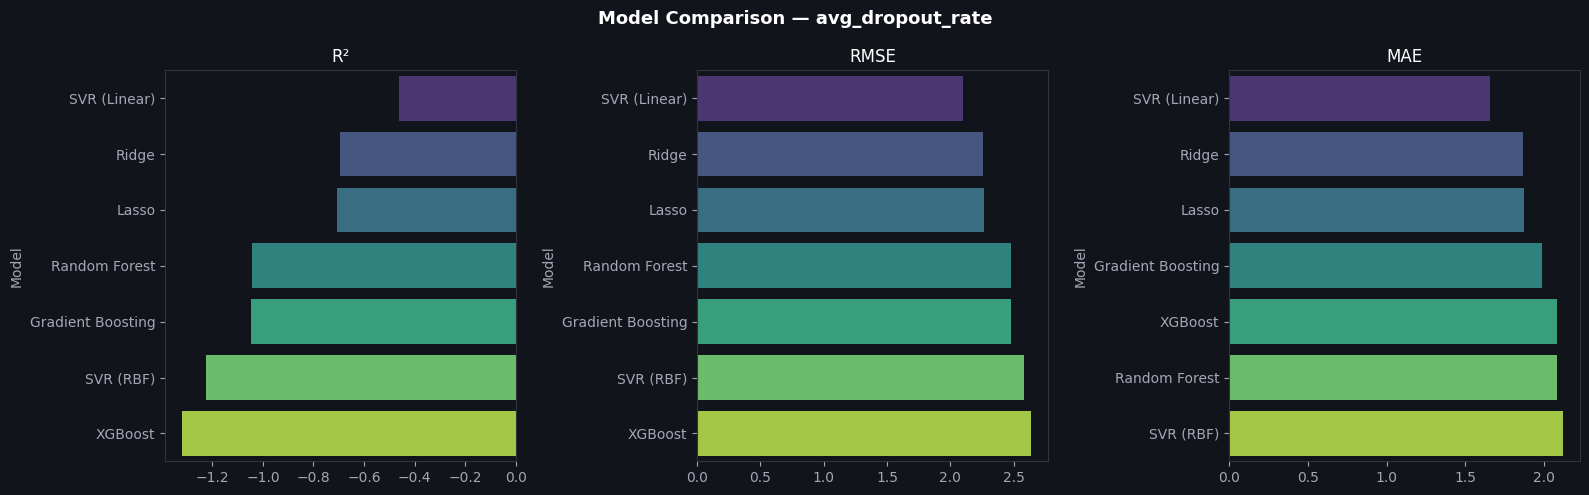

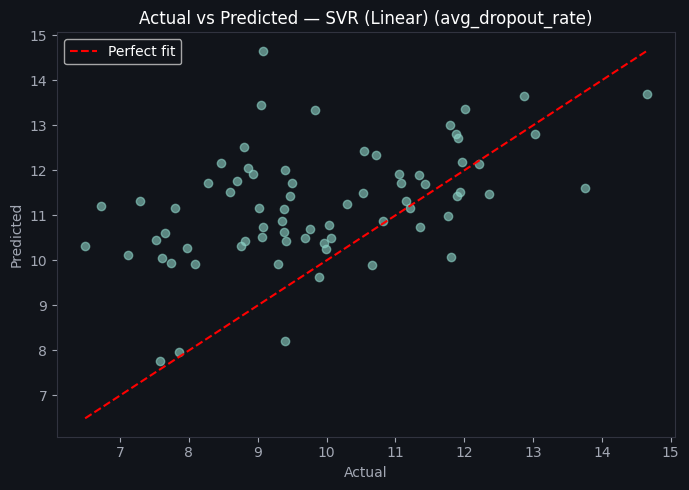

>>> TEACHER QUALITY

  TARGET: teaching_staff_edu_qual_index
            Model      R²   RMSE    MAE
        SVR (RBF)  0.1188 0.1505 0.1286
    Random Forest  0.1137 0.1509 0.1301
Gradient Boosting  0.0786 0.1539 0.1295
          XGBoost  0.0677 0.1548 0.1289
     SVR (Linear) -0.3288 0.1848 0.1522
            Ridge -0.4273 0.1916 0.1594
            Lasso -0.5871 0.2020 0.1727



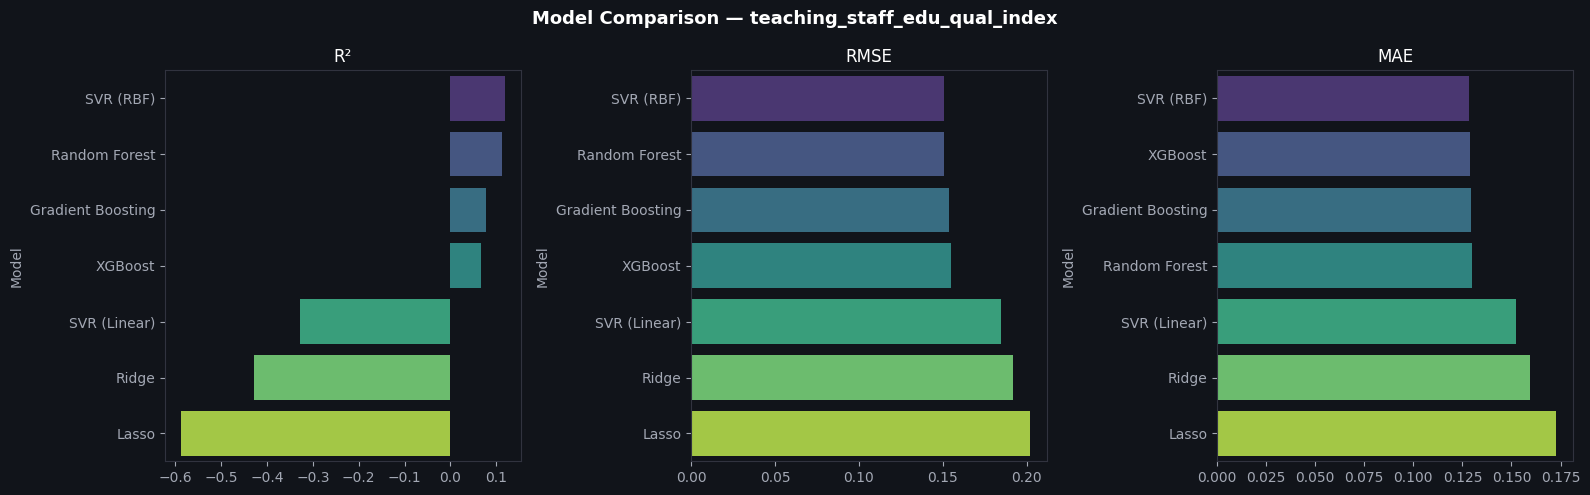

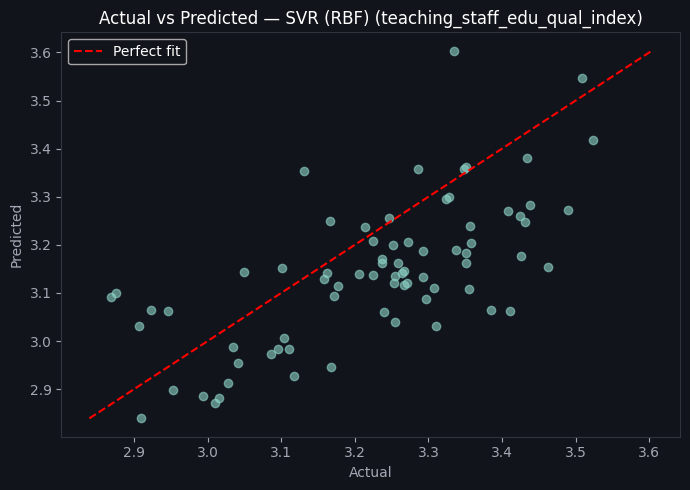

In [51]:
print(">>> DROPOUT RATE")
drop_out_transformed, pred_dropout = forecast_compare(
    drop_out_transformed, target='avg_dropout_rate', features=drop_out_feats, log_transform=False)

print(">>> TEACHER QUALITY")
res_teacher, pred_teacher = forecast_compare(
    teacher_transformed, target='teaching_staff_edu_qual_index', features=teacher_feats, log_transform=False)